In [1]:
import os
import kagglehub
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image

# ==========================================
# 1. 下載並設定 CelebA 資料集路徑
# ==========================================
print("開始下載/載入 CelebA 資料集...")
dataset_path = kagglehub.dataset_download("jessicali9530/celeba-dataset")
print(f"資料集準備完成，路徑: {dataset_path}")

img_dir = os.path.join(dataset_path, "img_align_celeba", "img_align_celeba")
attr_path = os.path.join(dataset_path, "list_attr_celeba.csv")
partition_path = os.path.join(dataset_path, "list_eval_partition.csv")

# ==========================================
# 2. 讀取資料並轉換標籤 (⚠️ 防禦 CUDA Error 的關鍵步驟)
# ==========================================
print("讀取標籤與切分設定，並進行資料清洗...")
df_attr = pd.read_csv(attr_path)
df_partition = pd.read_csv(partition_path)

df = pd.merge(df_attr, df_partition, on='image_id')

# 【關鍵防呆】將原本的 -1 與 1，強制轉換為 PyTorch 接受的 0 與 1
# 如果這裡沒轉乾淨，丟進 CrossEntropyLoss GPU 就會直接觸發 assert 崩潰！
df['Blond_Hair'] = (df['Blond_Hair'] == 1).astype(int)
df['Male'] = (df['Male'] == 1).astype(int)

# 再次確認沒有超出 0 和 1 的範圍
assert df['Blond_Hair'].isin([0, 1]).all(), "Blond_Hair 標籤轉換失敗！"
assert df['Male'].isin([0, 1]).all(), "Male 標籤轉換失敗！"

# ==========================================
# 3. 定義 Dataset 與 Transforms
# ==========================================
class CelebADataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.loc[idx, 'image_id']
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        target = torch.tensor(self.df.loc[idx, 'Blond_Hair'], dtype=torch.long)
        bias = torch.tensor(self.df.loc[idx, 'Male'], dtype=torch.long)
        return image, target, bias

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ==========================================
# 4. 切分資料集與計算交叉子群體
# ==========================================
df_train = df[df['partition'] == 0].reset_index(drop=True)
df_val   = df[df['partition'] == 1].reset_index(drop=True)
df_test  = df[df['partition'] == 2].reset_index(drop=True)

print(f"資料切分 -> Train: {len(df_train)}筆, Val: {len(df_val)}筆, Test: {len(df_test)}筆")

# 定義群體: 0(非金髮女), 1(非金髮男), 2(金髮女), 3(金髮男)
df_train['group'] = df_train['Blond_Hair'] * 2 + df_train['Male']
group_counts = df_train['group'].value_counts().sort_index()
print(f"訓練集群體分佈: \n{group_counts.to_dict()}")

# ==========================================
# 5. 準備 Group Balanced 策略的採樣器與資料表
# ==========================================
# (A) Oversampling 準備：計算每個樣本的權重
sample_weights = np.array([1.0 / group_counts[g] for g in df_train['group']])
sample_weights = torch.from_numpy(sample_weights).double()
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# (B) Undersampling 準備：將所有群體數量砍到跟最少數群體一樣多
min_count = group_counts.min()
print(f"\n執行 Undersampling，將所有群體數量縮減至最少數群體數量 ({min_count}筆)...")
df_train_under = df_train.groupby('group').sample(n=min_count, random_state=42).reset_index(drop=True)
print(f"Undersampled 訓練集總資料量: {len(df_train_under)}筆")

# ==========================================
# 6. 建立所有 DataLoader (⚠️ 全面使用 num_workers=0 防崩潰)
# ==========================================
batch_size = 128
print("\n建立 3 種 Train DataLoader 與 Val/Test DataLoader...")

train_dataset = CelebADataset(df_train, img_dir, transform=train_transform)
train_dataset_under = CelebADataset(df_train_under, img_dir, transform=train_transform)

val_dataset   = CelebADataset(df_val, img_dir, transform=eval_transform)
test_dataset  = CelebADataset(df_test, img_dir, transform=eval_transform)

# 1. Baseline (原生不平衡，隨機打亂)
train_loader_baseline = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, drop_last=True)

# 2. Oversampling (使用 Sampler，不可 shuffle)
train_loader_oversampled = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler, num_workers=0, drop_last=True)

# 3. Undersampling (向下採樣後的資料集，隨機打亂)
train_loader_undersampled = DataLoader(train_dataset_under, batch_size=batch_size, shuffle=True, num_workers=0, drop_last=True)

# Val / Test
val_loader  = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print("✅ 步驟 1 執行完畢！所有資料已安全載入。")

開始下載/載入 CelebA 資料集...
Using Colab cache for faster access to the 'celeba-dataset' dataset.
資料集準備完成，路徑: /kaggle/input/celeba-dataset
讀取標籤與切分設定，並進行資料清洗...
資料切分 -> Train: 162770筆, Val: 19867筆, Test: 19962筆
訓練集群體分佈: 
{0: 71629, 1: 66874, 2: 22880, 3: 1387}

執行 Undersampling，將所有群體數量縮減至最少數群體數量 (1387筆)...
Undersampled 訓練集總資料量: 5548筆

建立 3 種 Train DataLoader 與 Val/Test DataLoader...
✅ 步驟 1 執行完畢！所有資料已安全載入。


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet18, ResNet18_Weights

# ==========================================
# 1. 定義標準分類模型架構 (Standard ResNet18)
# ==========================================
class StandardResNet(nn.Module):
    def __init__(self, num_classes=2):
        super(StandardResNet, self).__init__()
        # 載入預訓練的 ResNet18 作為 Backbone
        self.backbone = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

        # 將最後一層替換為輸出 2 維 (0: 非金髮, 1: 金髮)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

# ==========================================
# 2. 定義群體加權損失函數 (Group-Weighted CE Loss)
# ==========================================
class GroupWeightedCrossEntropyLoss(nn.Module):
    def __init__(self, group_weights, device):
        super(GroupWeightedCrossEntropyLoss, self).__init__()
        self.group_weights = group_weights.to(device)

    def forward(self, logits, targets, biases):
        # 計算樣本所屬群體 (0:非金髮女, 1:非金髮男, 2:金髮女, 3:金髮男)
        groups = targets * 2 + biases
        weights = self.group_weights[groups]

        # 計算未平均的 CE Loss
        ce_loss = F.cross_entropy(logits, targets, reduction='none')

        # 乘上群體權重後取平均
        return (ce_loss * weights).mean()

def get_reweighted_loss(df_train, device):
    """計算群體權重並回傳 Group-Weighted CE Loss"""
    print("初始化 Group-Weighted CE Loss (Reweighting)...")
    groups = df_train['Blond_Hair'] * 2 + df_train['Male']
    group_counts = groups.value_counts().sort_index().values

    # 計算倒數並正規化 (避免 Loss 數值過小導致梯度消失)
    raw_weights = 1.0 / group_counts
    normalized_weights = raw_weights / raw_weights.mean()
    weight_tensor = torch.tensor(normalized_weights, dtype=torch.float32)

    print(f"✅ Reweighting 正規化權重: {weight_tensor.tolist()}")
    return GroupWeightedCrossEntropyLoss(weight_tensor, device)

# ==========================================
# 3. 定義群體感知焦點損失 (Group-Weighted Focal Loss)
# ==========================================
class GroupWeightedFocalLoss(nn.Module):
    def __init__(self, group_weights, device, gamma=2.0):
        super(GroupWeightedFocalLoss, self).__init__()
        self.group_weights = group_weights.to(device)
        self.gamma = gamma

    def forward(self, logits, targets, biases):
        groups = targets * 2 + biases
        weights = self.group_weights[groups]

        # 計算基礎 CE Loss (不平均)
        ce_loss = F.cross_entropy(logits, targets, reduction='none')

        # 計算 pt (模型預測正確類別的機率)
        pt = torch.exp(-ce_loss)

        # 結合 Focal Loss 公式與群體權重
        focal_loss = weights * ((1 - pt) ** self.gamma * ce_loss)

        return focal_loss.mean()

def get_focal_loss(df_train, device):
    """計算群體權重並回傳 Group-Weighted Focal Loss"""
    print("初始化 Group-Weighted Focal Loss (Focal)...")
    groups = df_train['Blond_Hair'] * 2 + df_train['Male']
    group_counts = groups.value_counts().sort_index().values

    raw_weights = 1.0 / group_counts
    normalized_weights = raw_weights / raw_weights.mean()
    weight_tensor = torch.tensor(normalized_weights, dtype=torch.float32)

    print(f"✅ Focal Loss 正規化權重: {weight_tensor.tolist()} (gamma=2.0)")
    return GroupWeightedFocalLoss(weight_tensor, device, gamma=2.0)

# ==========================================
# 4. 簡單測試 (確保模型與 Loss 函數無報錯)
# ==========================================
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    _test_model = StandardResNet(num_classes=2).to(device)
    print("✅ 模型架構實例化成功！")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 217MB/s]


✅ 模型架構實例化成功！


In [3]:
import torch
import copy
import time
from tqdm import tqdm

# ==========================================
# 步驟 3：支援雙重儲存與多種 Loss 的訓練迴圈
# ==========================================
def train_debias_model(model, train_loader, val_loader, criterion, optimizer, device,
                       num_epochs=5, method_name='Baseline', loss_type='CE'):
    """
    執行模型訓練，並依據 Worst-group Acc 與 EOD 進行雙重存檔。

    loss_type: 'CE' (標準), 'Reweighting' (群體加權), 'Focal' (焦點損失)
    """
    print(f"\n🚀 啟動實驗: [{method_name}] | Loss 類型: {loss_type}")

    # 初始化追蹤指標
    best_wg_acc = 0.0
    best_eod = float('inf')

    # 準備存檔路徑
    save_path_wg = f'best_wg_model_{method_name}.pth'
    save_path_eod = f'best_eod_model_{method_name}.pth'

    # 歷史紀錄
    history = {'train_loss': [], 'val_loss': [], 'overall_acc': [], 'worst_group_acc': [], 'eod': []}

    for epoch in range(num_epochs):
        start_time = time.time()

        # ---------------------------
        # [訓練階段]
        # ---------------------------
        model.train()
        running_loss = 0.0

        train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False)
        for images, targets, biases in train_bar:
            images, targets, biases = images.to(device), targets.to(device), biases.to(device)

            optimizer.zero_grad()
            logits = model(images)

            # 💡 依據 Loss 類型動態決定是否傳入 biases
            if loss_type in ['Reweighting', 'Focal']:
                loss = criterion(logits, targets, biases)
            else:
                loss = criterion(logits, targets)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            train_bar.set_postfix({'Loss': f"{loss.item():.4f}"})

        epoch_train_loss = running_loss / len(train_loader.dataset)

        # ---------------------------
        # [驗證階段]
        # ---------------------------
        model.eval()
        val_loss = 0.0

        all_preds, all_targets, all_biases = [], [], []

        val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]  ", leave=False)
        with torch.no_grad():
            for images, targets, biases in val_bar:
                images, targets, biases = images.to(device), targets.to(device), biases.to(device)
                logits = model(images)

                # 計算 Val Loss (同樣需判斷 Loss 類型)
                if loss_type in ['Reweighting', 'Focal']:
                    loss = criterion(logits, targets, biases)
                else:
                    loss = criterion(logits, targets)

                val_loss += loss.item() * images.size(0)

                # 收集預測結果
                preds = torch.argmax(logits, dim=1)
                all_preds.append(preds.cpu())
                all_targets.append(targets.cpu())
                all_biases.append(biases.cpu())

        # 合併所有 Batch 的結果
        all_preds = torch.cat(all_preds)
        all_targets = torch.cat(all_targets)
        all_biases = torch.cat(all_biases)

        # ---------------------------
        # [計算評估指標]
        # ---------------------------
        epoch_val_loss = val_loss / len(val_loader.dataset)

        # 1. Overall Accuracy
        epoch_overall_acc = (all_preds == all_targets).float().mean().item()

        # 2. Worst-group Accuracy
        groups = [(0, 0), (0, 1), (1, 0), (1, 1)]
        group_accs = []
        for t, b in groups:
            mask = (all_targets == t) & (all_biases == b)
            if mask.sum() > 0:
                acc = (all_preds[mask] == all_targets[mask]).float().mean().item()
                group_accs.append(acc)
        epoch_worst_acc = min(group_accs) if group_accs else 0.0

        # 3. Equal Opportunity Difference (EOD)
        # TPR = 在 target=1 (金髮) 的情況下，預測為 1 的比例
        mask_t1_b0 = (all_targets == 1) & (all_biases == 0)
        mask_t1_b1 = (all_targets == 1) & (all_biases == 1)

        tpr_b0 = (all_preds[mask_t1_b0] == 1).float().mean().item() if mask_t1_b0.sum() > 0 else 0.0
        tpr_b1 = (all_preds[mask_t1_b1] == 1).float().mean().item() if mask_t1_b1.sum() > 0 else 0.0
        epoch_eod = abs(tpr_b0 - tpr_b1)

        # 儲存歷史紀錄
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['overall_acc'].append(epoch_overall_acc)
        history['worst_group_acc'].append(epoch_worst_acc)
        history['eod'].append(epoch_eod)

        # 印出 Epoch 總結
        epoch_time = time.time() - start_time
        print(f"Epoch {epoch+1:02d} | 耗時: {epoch_time:.0f}s | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")
        print(f"         ➔ Overall Acc: {epoch_overall_acc:.4f} | WG Acc: {epoch_worst_acc:.4f} | EOD: {epoch_eod:.4f}")

        # ---------------------------
        # [雙重存檔邏輯]
        # ---------------------------
        # 策略 A：最差群體準確率破紀錄
        if epoch_worst_acc > best_wg_acc:
            print(f"   🏆 [WG Acc 破紀錄] {best_wg_acc:.4f} ➔ {epoch_worst_acc:.4f} | 存檔中...")
            best_wg_acc = epoch_worst_acc
            torch.save(model.state_dict(), save_path_wg)

        # 策略 B：EOD 破紀錄 (且 Overall Acc 大於 0.85 防崩潰)
        if epoch_eod < best_eod and epoch_overall_acc > 0.85:
            print(f"   ⚖️ [EOD 破紀錄] {best_eod:.4f} ➔ {epoch_eod:.4f} (Overall Acc > 85%) | 存檔中...")
            best_eod = epoch_eod
            torch.save(model.state_dict(), save_path_eod)

    print("-" * 60)
    print(f"✅ [{method_name}] 訓練完成！最佳 WG Acc: {best_wg_acc:.4f} | 最佳 EOD: {best_eod:.4f}")
    return history

In [4]:
import torch

# ==========================================
# 步驟 4：模型評估與 Fairness 數據收集函式
# ==========================================
def evaluate_model(model, test_loader, device, model_path):
    """
    載入指定權重，在 Test DataLoader 上推論，並計算 Accuracy 與 Fairness 指標。
    """
    # 載入模型權重 (加上 weights_only=True 提升安全性)
    model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    model.eval()

    all_preds = []
    all_targets = []
    all_biases = []

    # 關閉梯度計算，加速推論並節省 GPU 記憶體
    with torch.no_grad():
        for images, targets, biases in test_loader:
            images = images.to(device)

            # 取得預測結果
            logits = model(images)
            preds = torch.argmax(logits, dim=1)

            # 將結果移回 CPU 並收集
            all_preds.append(preds.cpu())
            all_targets.append(targets.cpu())
            all_biases.append(biases.cpu())

    # 將 List 合併成一維 Tensor 方便運算
    all_preds = torch.cat(all_preds)
    all_targets = torch.cat(all_targets)
    all_biases = torch.cat(all_biases)

    # ==========================================
    # 計算 4 大核心指標
    # ==========================================

    # 1. Overall Accuracy (整體準確率)
    overall_acc = (all_preds == all_targets).float().mean().item()

    # 2. Worst-group Accuracy (最差群體準確率)
    groups = [(0, 0), (0, 1), (1, 0), (1, 1)]
    group_accs = []
    for t, b in groups:
        mask = (all_targets == t) & (all_biases == b)
        if mask.sum() > 0:
            acc = (all_preds[mask] == all_targets[mask]).float().mean().item()
            group_accs.append(acc)
    worst_group_acc = min(group_accs) if group_accs else 0.0

    # 3. Equal Opportunity Difference (EOD)
    # 在 Target=1 (金髮) 條件下，預測為 1 的比例差異
    mask_t1_b0 = (all_targets == 1) & (all_biases == 0)
    mask_t1_b1 = (all_targets == 1) & (all_biases == 1)

    tpr_b0 = (all_preds[mask_t1_b0] == 1).float().mean().item() if mask_t1_b0.sum() > 0 else 0.0
    tpr_b1 = (all_preds[mask_t1_b1] == 1).float().mean().item() if mask_t1_b1.sum() > 0 else 0.0
    eod = abs(tpr_b0 - tpr_b1)

    # 4. Demographic Parity Difference (DPD)
    # 不管真實標籤，預測為 1 的總比例差異
    mask_b0 = (all_biases == 0)
    mask_b1 = (all_biases == 1)

    pr_b0 = (all_preds[mask_b0] == 1).float().mean().item() if mask_b0.sum() > 0 else 0.0
    pr_b1 = (all_preds[mask_b1] == 1).float().mean().item() if mask_b1.sum() > 0 else 0.0
    dpd = abs(pr_b0 - pr_b1)

    # 印出精簡 Log (萃取檔名以便辨識)
    model_name = model_path.split('/')[-1].replace('.pth', '')
    print(f"✅ 評估完成 [{model_name}] ➔ Overall Acc: {overall_acc:.3f} | WG Acc: {worst_group_acc:.3f} | EOD: {eod:.3f} | DPD: {dpd:.3f}")

    # 回傳結果字典
    return {
        'overall_acc': overall_acc,
        'worst_group_acc': worst_group_acc,
        'eod': eod,
        'dpd': dpd
    }


🌟 啟動終極自動化實驗流程，共計 5 組大車拼...

▶️ 開始訓練: Baseline...

🚀 啟動實驗: [Baseline] | Loss 類型: CE


Epoch 01 | 耗時: 2532s | Train Loss: 0.1215 | Val Loss: 0.1055
         ➔ Overall Acc: 0.9567 | WG Acc: 0.4505 | EOD: 0.4325
   🏆 [WG Acc 破紀錄] 0.0000 ➔ 0.4505 | 存檔中...
   ⚖️ [EOD 破紀錄] inf ➔ 0.4325 (Overall Acc > 85%) | 存檔中...


Epoch 02 | 耗時: 1188s | Train Loss: 0.1024 | Val Loss: 0.1092
         ➔ Overall Acc: 0.9553 | WG Acc: 0.3462 | EOD: 0.5488


Epoch 03 | 耗時: 1145s | Train Loss: 0.0955 | Val Loss: 0.1063
         ➔ Overall Acc: 0.9560 | WG Acc: 0.3956 | EOD: 0.4656
------------------------------------------------------------
✅ [Baseline] 訓練完成！最佳 WG Acc: 0.4505 | 最佳 EOD: 0.4325

▶️ 開始訓練: Oversampling...

🚀 啟動實驗: [Oversampling] | Loss 類型: CE


Epoch 01 | 耗時: 1160s | Train Loss: 0.1355 | Val Loss: 0.1379
         ➔ Overall Acc: 0.9460 | WG Acc: 0.6429 | EOD: 0.2785
   🏆 [WG Acc 破紀錄] 0.0000 ➔ 0.6429 | 存檔中...
   ⚖️ [EOD 破紀錄] inf ➔ 0.2785 (Overall Acc > 85%) | 存檔中...


...

Epoch 02 | 耗時: 1128s | Train Loss: 0.0244 | Val Loss: 0.0244
         ➔ Overall Acc: 0.9022 | WG Acc: 0.8602 | EOD: 0.0195


Epoch 03 | 耗時: 1138s | Train Loss: 0.0231 | Val Loss: 0.0268
         ➔ Overall Acc: 0.8978 | WG Acc: 0.8560 | EOD: 0.0353
------------------------------------------------------------
✅ [Reweighting] 訓練完成！最佳 WG Acc: 0.8691 | 最佳 EOD: 0.0105

▶️ 開始訓練: Focal Loss...
初始化 Group-Weighted Focal Loss (Focal)...
✅ Focal Loss 正規化權重: [0.07036696374416351, 0.07537032663822174, 0.22029350697994232, 3.633969306945801] (gamma=2.0)

🚀 啟動實驗: [Focal Loss] | Loss 類型: Focal


Epoch 01 | 耗時: 1159s | Train Loss: 0.0084 | Val Loss: 0.0070
         ➔ Overall Acc: 0.8962 | WG Acc: 0.8717 | EOD: 0.0105
   🏆 [WG Acc 破紀錄] 0.0000 ➔ 0.8717 | 存檔中...
   ⚖️ [EOD 破紀錄] inf ➔ 0.0105 (Overall Acc > 85%) | 存檔中...


Epoch 02 | 耗時: 1176s | Train Loss: 0.0068 | Val Loss: 0.0107
         ➔ Overall Acc: 0.7673 | WG Acc: 0.7052 | EOD: 0.0095


Epoch 03 | 耗時: 1164s | Train Loss: 0.0067 | Val Loss: 0.0071
         ➔ Overall Acc: 0.8943 | WG Acc: 0.8654 | EOD: 0.0073
   ⚖️ [EOD 破紀錄] 0.0105 ➔ 0.0073 (Overall Acc > 85%) | 存檔中...
------------------------------------------------------------
✅ [Focal Loss] 訓練完成！最佳 WG Acc: 0.8717 | 最佳 EOD: 0.0073

📊 訓練完畢！開始評估所有模型並收集數據...
✅ 評估完成 [best_wg_model_Baseline] ➔ Overall Acc: 0.960 | WG Acc: 0.439 | EOD: 0.439 | DPD: 0.193
✅ 評估完成 [best_eod_model_Baseline] ➔ Overall Acc: 0.960 | WG Acc: 0.439 | EOD: 0.439 | DPD: 0.193
✅ 評估完成 [best_wg_model_Oversampling] ➔ Overall Acc: 0.951 | WG Acc: 0.561 | EOD: 0.355 | DPD: 0.199
✅ 評估完成 [best_eod_model_Oversampling] ➔ Overall Acc: 0.951 | WG Acc: 0.561 | EOD: 0.355 | DPD: 0.199
✅ 評估完成 [best_wg_model_Undersampling] ➔ Overall Acc: 0.921 | WG Acc: 0.856 | EOD: 0.041 | DPD: 0.151
✅ 評估完成 [best_eod_model_Undersampling] ➔ Overall Acc: 0.884 | WG Acc: 0.867 | EOD: 0.024 | DPD: 0.160
✅ 評估完成 [best_wg_model_Reweighting] ➔ Overall Acc: 0.893 | WG Acc: 0.878 | EOD: 0.015

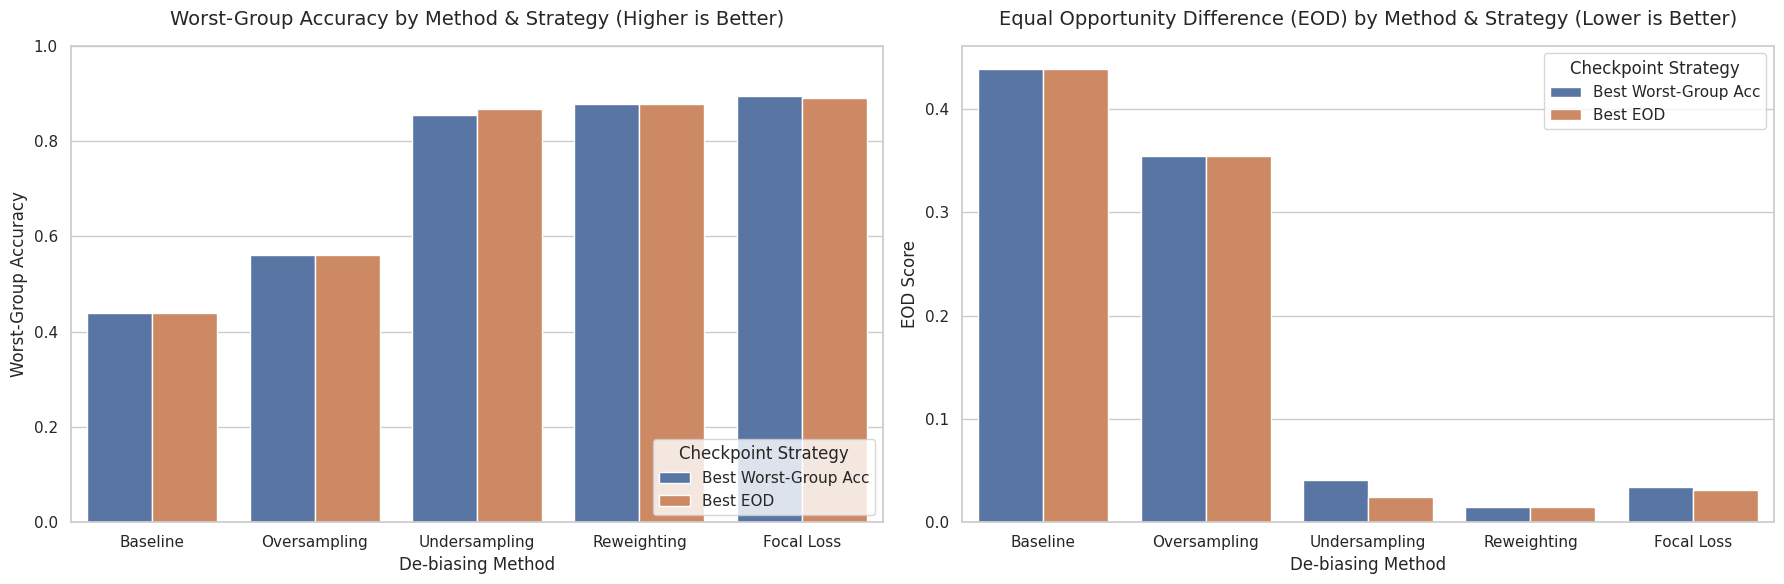

In [5]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 實驗總管與超參數設定
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
EPOCHS = 3  # 💡 測試階段設為 2，確認沒問題後改為 10-15 跑最終數據
LR = 1e-4

# 定義 5 種實驗設定的終極清單
experiments = [
    {
        'name': 'Baseline',
        'loader': train_loader_baseline,
        'loss_type': 'CE'
    },
    {
        'name': 'Oversampling',
        'loader': train_loader_oversampled,
        'loss_type': 'CE'
    },
    {
        'name': 'Undersampling',
        'loader': train_loader_undersampled,
        'loss_type': 'CE'
    },
    {
        'name': 'Reweighting',
        'loader': train_loader_baseline,
        'loss_type': 'Reweighting'
    },
    {
        'name': 'Focal Loss',
        'loader': train_loader_baseline,
        'loss_type': 'Focal'
    }
]

print("\n" + "="*60)
print(f"🌟 啟動終極自動化實驗流程，共計 {len(experiments)} 組大車拼...")
print("="*60)

# ==========================================
# 2. 自動化訓練迴圈
# ==========================================
for exp in experiments:
    print(f"\n▶️ 開始訓練: {exp['name']}...")

    # 【關鍵防污染】每次實驗必須重新初始化一顆全新的 ResNet18 大腦
    model = StandardResNet(num_classes=2).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

    # 根據實驗設定，實例化對應的 Loss 函數
    if exp['loss_type'] == 'CE':
        criterion = nn.CrossEntropyLoss().to(device)
    elif exp['loss_type'] == 'Reweighting':
        criterion = get_reweighted_loss(df_train, device)
    elif exp['loss_type'] == 'Focal':
        criterion = get_focal_loss(df_train, device)

    # 呼叫步驟 3 的訓練函式
    train_debias_model(
        model=model,
        train_loader=exp['loader'],
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        num_epochs=EPOCHS,
        method_name=exp['name'],
        loss_type=exp['loss_type']
    )

# ==========================================
# 3. 自動化評估與數據收集 (10 個模型)
# ==========================================
print("\n" + "="*60)
print("📊 訓練完畢！開始評估所有模型並收集數據...")
print("="*60)

results = []
save_strategies = [
    ('Best Worst-Group Acc', 'best_wg_model_'),
    ('Best EOD', 'best_eod_model_')
]

for exp in experiments:
    method_name = exp['name']
    for strategy_name, file_prefix in save_strategies:
        model_path = f"{file_prefix}{method_name}.pth"

        if os.path.exists(model_path):
            # 初始化空模型以載入權重
            eval_model = StandardResNet(num_classes=2).to(device)
            # 呼叫步驟 4 的評估函式
            metrics = evaluate_model(eval_model, test_loader, device, model_path)

            results.append({
                'Method': method_name,
                'Save Strategy': strategy_name,
                'Overall_Acc': metrics['overall_acc'],
                'Worst_Group_Acc': metrics['worst_group_acc'],
                'EOD': metrics['eod'],
                'DPD': metrics['dpd']
            })
        else:
            print(f"⚠️ 找不到檔案: {model_path} (可能該策略未能觸發存檔門檻)")

# ==========================================
# 4. 整理 DataFrame 並匯出 CSV
# ==========================================
df_results = pd.DataFrame(results)
print("\n" + "="*60)
print("📝 最終實驗結果總表")
print("="*60)
print(df_results.to_string(index=False))

df_results.to_csv('debiasing_methods_comparison.csv', index=False)
print("\n✅ 數據已安全匯出為 'debiasing_methods_comparison.csv'")

# ==========================================
# 5. 數據視覺化 (Grouped Bar Charts)
# ==========================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 6)) # 稍微加寬以容納 5 組

# 設定 5 種方法的固定排序，讓圖表更易讀
order = ['Baseline', 'Oversampling', 'Undersampling', 'Reweighting', 'Focal Loss']

# --- 左圖：Worst-Group Accuracy (越高越好) ---
sns.barplot(
    data=df_results,
    x='Method',
    y='Worst_Group_Acc',
    hue='Save Strategy',
    palette=['#4C72B0', '#DD8452'],
    order=order,
    ax=axes[0]
)
axes[0].set_title('Worst-Group Accuracy by Method & Strategy (Higher is Better)', fontsize=14, pad=15)
axes[0].set_xlabel('De-biasing Method', fontsize=12)
axes[0].set_ylabel('Worst-Group Accuracy', fontsize=12)
axes[0].set_ylim(0, 1.0)
axes[0].legend(title='Checkpoint Strategy', loc='lower right')

# --- 右圖：EOD (越低越好) ---
sns.barplot(
    data=df_results,
    x='Method',
    y='EOD',
    hue='Save Strategy',
    palette=['#4C72B0', '#DD8452'],
    order=order,
    ax=axes[1]
)
axes[1].set_title('Equal Opportunity Difference (EOD) by Method & Strategy (Lower is Better)', fontsize=14, pad=15)
axes[1].set_xlabel('De-biasing Method', fontsize=12)
axes[1].set_ylabel('EOD Score', fontsize=12)
axes[1].legend(title='Checkpoint Strategy', loc='upper right')

# 微調版面並存檔
plt.tight_layout()
plt.savefig('debiasing_comparison_plot.png', dpi=300, bbox_inches='tight')
print("✅ 圖表已儲存為 'debiasing_comparison_plot.png'")
plt.show()